# Proyecto Integrador de Aprendizaje Automático

En este proyecto tenemos como objetivo analizar el conjunto de datos clínicos relacionados con la presencia de enfermedades cardíacas. Estudiarlos es de gran importancia para quienes trabajan en el ámbito médico ya que permite identificar patrones y factores de riesgo que influyen en la salud cardiovascular de los pacientes.

Para iniciar, requerimos de las siguientes librerías:

In [165]:
import math
import warnings
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, Binarizer, FunctionTransformer
from sklearn.preprocessing import KBinsDiscretizer  
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

Leemos la base:

In [166]:
from ucimlrepo import fetch_ucirepo 
# fetch del dataset
heart_disease = fetch_ucirepo(id=45) 

# guardar features y target por separado 
dff = heart_disease.data.features
dft = heart_disease.data.targets

# unión de los dataframe
def juntar_dataframes(df1, df2):
    return pd.concat([df1, df2], axis=1)

df = juntar_dataframes(dff, dft)
# info general
print(heart_disease.metadata) 
# descripción de variables   
print(heart_disease.variables)   
df.head()

{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


Unimos los dataframes:

In [167]:
dff=heart_disease.data.features

In [168]:
dft=heart_disease.data.targets

In [169]:
def juntar_dataframes(df1, df2):
    return pd.concat([df1, df2], axis=1)

In [170]:
df=juntar_dataframes(dff, dft)

Identificamos factores y naturaleza de las variables del dataset:

In [171]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [172]:
df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
5,56,1,2,120,236,0,0,178,0,0.8,1,0.0,3.0,0
6,62,0,4,140,268,0,2,160,0,3.6,3,2.0,3.0,3
7,57,0,4,120,354,0,0,163,1,0.6,1,0.0,3.0,0
8,63,1,4,130,254,0,2,147,0,1.4,2,1.0,7.0,2
9,53,1,4,140,203,1,2,155,1,3.1,3,0.0,7.0,1


In [173]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


Ahora, revisamos si hay presencia de datos faltantes:

In [174]:
def Nas_porcentaje_columnas(dataframe):
    total_nas = dataframe.isnull().sum()
    porcentaje_nas = (total_nas / len(dataframe)) * 100
    nas_df = pd.DataFrame({'Total_NAs': total_nas, 'Porcentaje_NAs': porcentaje_nas})
    return nas_df   
Nas_porcentaje_columnas(df)

,Total_NAs,Porcentaje_NAs
age,0,0.000000
sex,0,0.000000
cp,0,0.000000
trestbps,0,0.000000
chol,0,0.000000
fbs,0,0.000000
restecg,0,0.000000
thalach,0,0.000000
exang,0,0.000000
oldpeak,0,0.000000


In [175]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [176]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

Para las dos variables que presentaron un conteo de nulos bastante pequeño, hacemos dicha imputación con la moda pues son variables categóricas.

In [177]:
df["ca"].fillna(df["ca"].mode()[0], inplace=True)
df["thal"].fillna(df["thal"].mode()[0], inplace=True)

In [178]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

Con el tratamiento de faltantes hecho, visualizamos las distrubuciones de las variables numéricas:

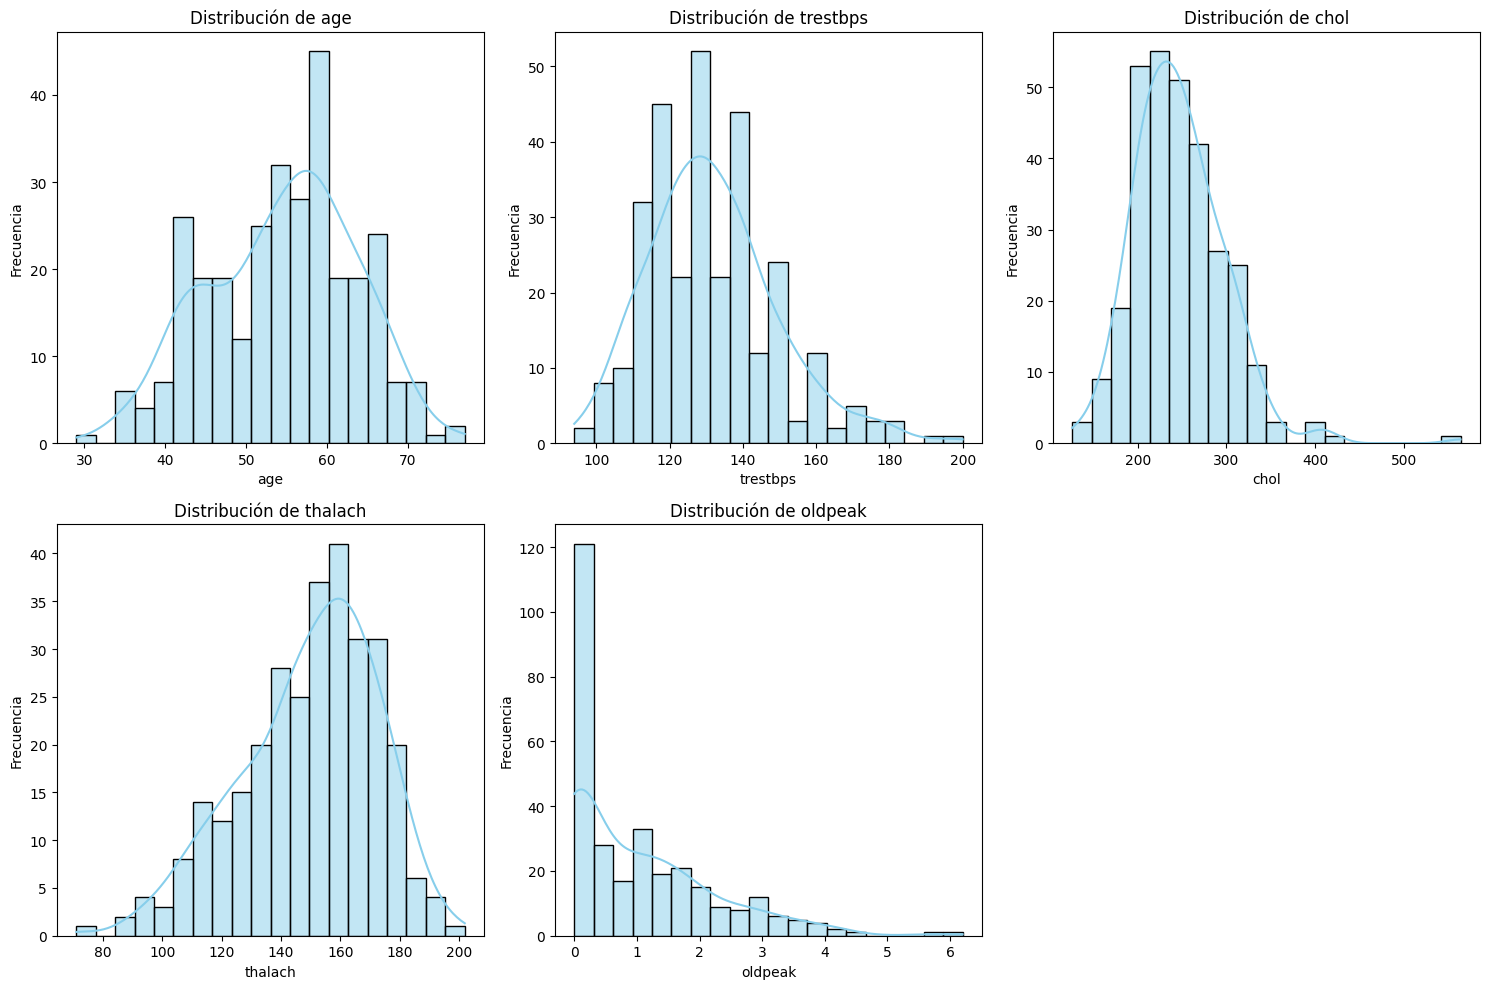

In [179]:
# numéricas principales
num_vars = ["age", "trestbps", "chol", "thalach", "oldpeak"]
n = len(num_vars)
cols = 3 
rows = math.ceil(n / cols)  
fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
axes = axes.flatten()

for i, var in enumerate(num_vars):
    sns.histplot(df[var], bins=20, kde=True, color="skyblue", ax=axes[i])
    axes[i].set_title(f"Distribución de {var}")
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Frecuencia")

# quitamos ejes sobrantes 
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


Mediante estás visualizaciones de las distribuciones vemos que para la variable edad su distribución se ve nastante normal y centrada entre los 50 y 60 años. También hay un rango desde los 30 hasta casi los 70, es decir, que pudieran contener el conjunto de datos contiene adultos de mediana y tercera edad, por lo que indica que eset grupo tiene mayor riesgo de enfermedades cardíacas.

En la distrbución de la variable de presión arterial en reposo presenta una distribución donde la mayoría de valores están entre 110 y 150 mmHg, siendo pacientes con posibles casos de hipertensión.

En la distribución de la variable sobre colesterol sérico ña mayor parte de los valores están entre 200 y 300 mg/dl, pero con valores extremos que superan los 500, por lo que hay casos de hipercolesterolemia alta.

En la distribución de la variable de frecuencia cardíaca máxima alcanzada tiene como una forma de campana con valores entre 140 y 170 lpm.

En la distribución de la variable de depresión del segmento se ve que la mayoría de los pacientes tiene valores cercanos a 0 y algunos alcanzan hasta 6, y pueden estar asociados a la mayor probabilidad de presentar la enfermedad cardíaca.

Ahora haremos un comparativo:

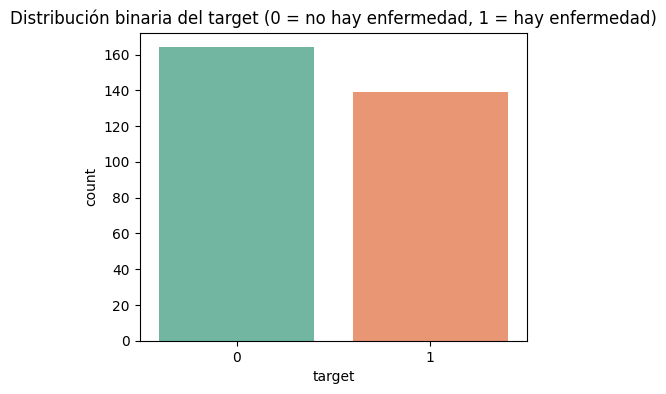

In [180]:
df['target'] = (df['num'] > 0).astype(int)

numeric_vars = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca'] 
categorical_vars = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

# distribución del target 
plt.figure(figsize=(5,4))
sns.countplot(x='target', data=df, palette="Set2")
plt.title("Distribución binaria del target (0 = no hay enfermedad, 1 = hay enfermedad)")
plt.show()

Para nuestra variable target que la presencia o ausencia de la enfermedad cardíaca, se muestra que el grupo de pacientes sin enfermedad es un poc mayor, con uno 165 casos, mientras que el grupo con diagnóstico positivo tiene unos 140 casos.
La diferencia entre los dos no es muy grande pues el conjunto de datos se encuentra balanceado. 

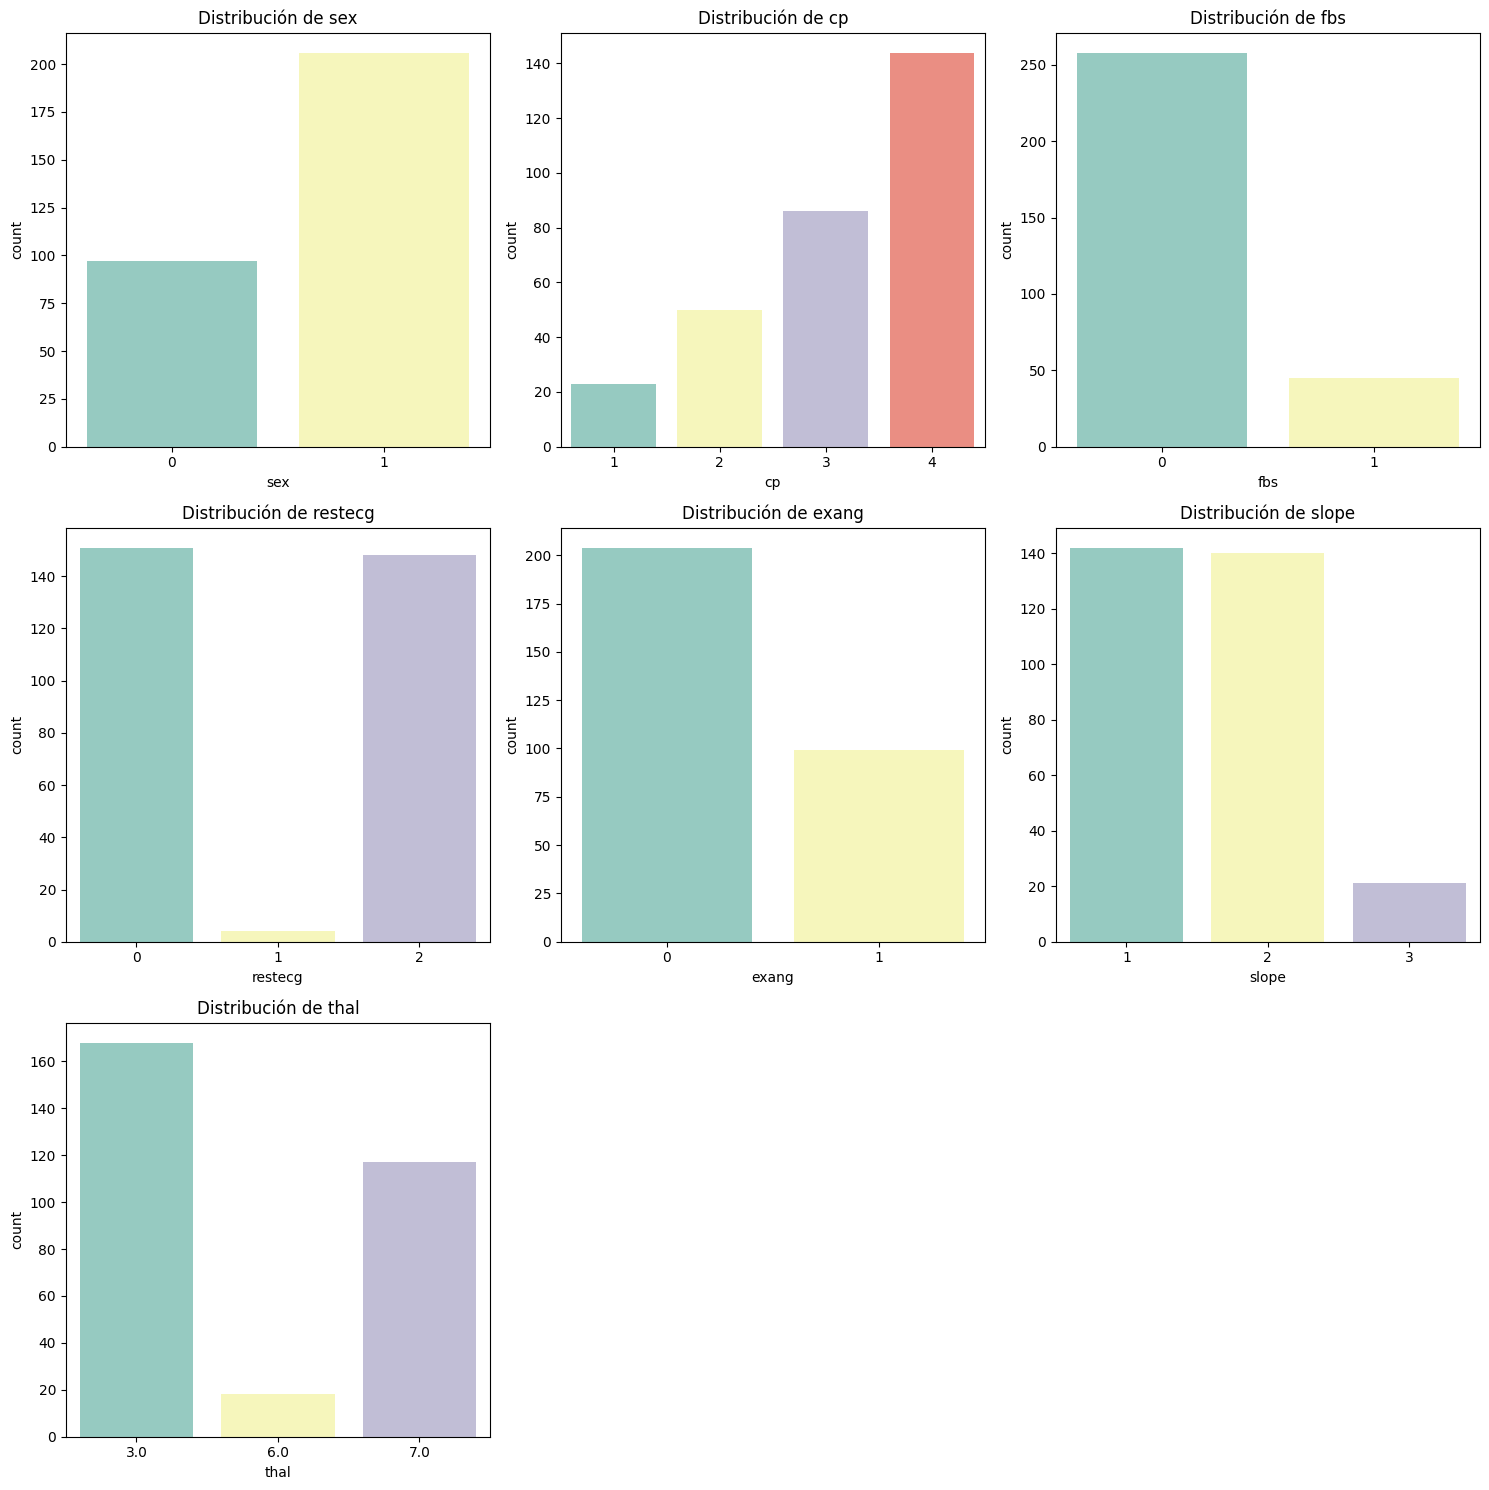

In [181]:
# variables categóricas
n = len(categorical_vars)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
axes = axes.flatten()

for i, var in enumerate(categorical_vars):
    sns.countplot(x=var, data=df, ax=axes[i], palette="Set3")
    axes[i].set_title(f"Distribución de {var}")

# quitar ejes vacíos
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


Vemos que la variable sex muestra que la mayoría de los pacientes son del sexo masculino. Con la variable cp, que es el tipo de dolor en el pecho, el valor más común es el 4 y el 1 es el menor. 

En la variable fbs, siendo el azúcar en sangre en ayunas, la gran mayoría tiene un valor de 0, es decir, menor a 120 mg/dl, mientras que son pocos los que presentan un valor de 1 o mayor a 120 mg/dl.

En la distribución de restecg, siendo los resultados del electrocardiograma en reposo, los valores están 0 y 2, y el valor 1 aparece menos.

La variable exang, siendo la angina inducida por el ejercicio, muestra que la mayoría de los pacientes no presentan angina inducida mientras que un grupo menor con el valor 1 sí la presenta. 

En slope, es decir, el pendiente del segmento durante el ejercicio máximo, los valores 1 y 2 son más frecuentes, mientras que el 3 es poco común. Y en la variable de talasemia los valores más frecuentes son 3 y 7, mientras que el valor 6 es el menor en la muestra.

Todos estos análisis muestran que ciertas condiciones clínicas son mucho más frecuentes dentro de la muestra dada y que podrían estar relacionadas con la probabilidad de desarrollar una enfermedad cardíaca.

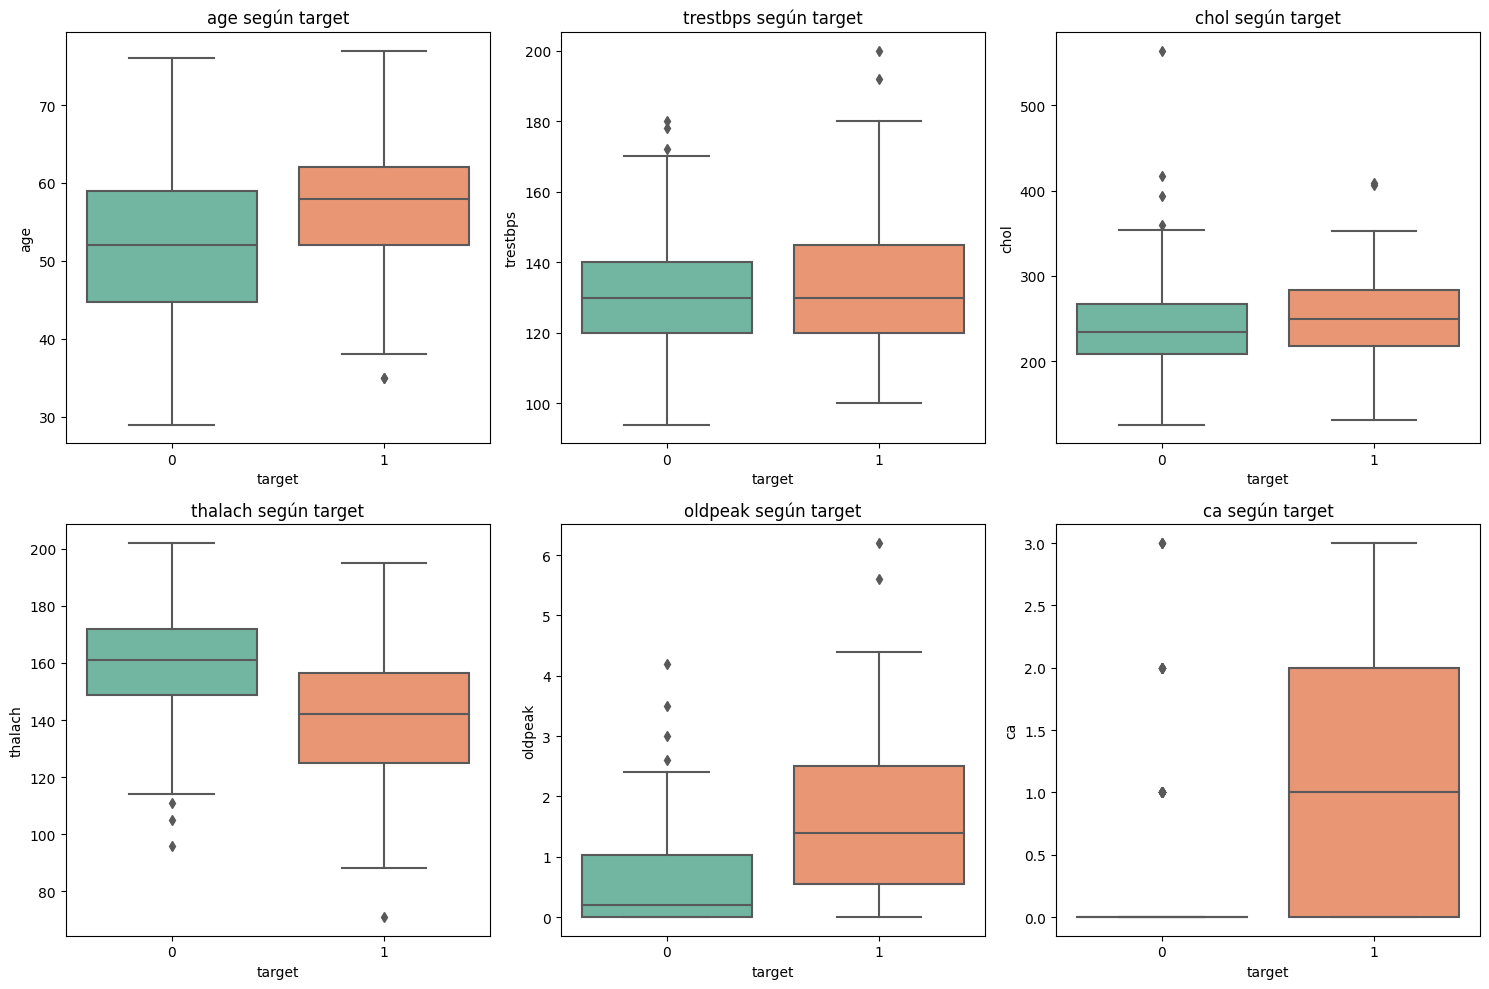

In [182]:
# numéricas vs target
n = len(numeric_vars)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
axes = axes.flatten()

for i, var in enumerate(numeric_vars):
    sns.boxplot(x='target', y=var, data=df, ax=axes[i], palette="Set2")
    axes[i].set_title(f"{var} según target")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

En este análisis de los boxplots vimos que en la variable edad los pacientes con enfermedad tienden a tener una edad mayor a diferencia de quienes son más jóvenes.

En cuanto a la presión arterial en reposo los pacientes con enfermedad muestran una mayor dispersión en los valores con cifras más elevadas de quienes no presentan. En la variable de colesterol los valores son similares entre ambos grupos pero los pacientes con enfermedad tienen casos con niveles más altos y una dispersión mayor.

En el caso de la frecuencia cardíaca máxima alcanzada los pacientes con enfermedad alcanzan una frecuencia cardíaca más baja que quienen no tienen la enfermedad. 

Para la variable depresión del ST los pacientes con enfermedad presentan valores más altos en comparación con los que no tienen, y en el número de vasos coloreados los pacientes sin enfermedad se encuentran en el valor 0, mientras que los que presentan enfermedad muestran un mayor número de vasos afectados.

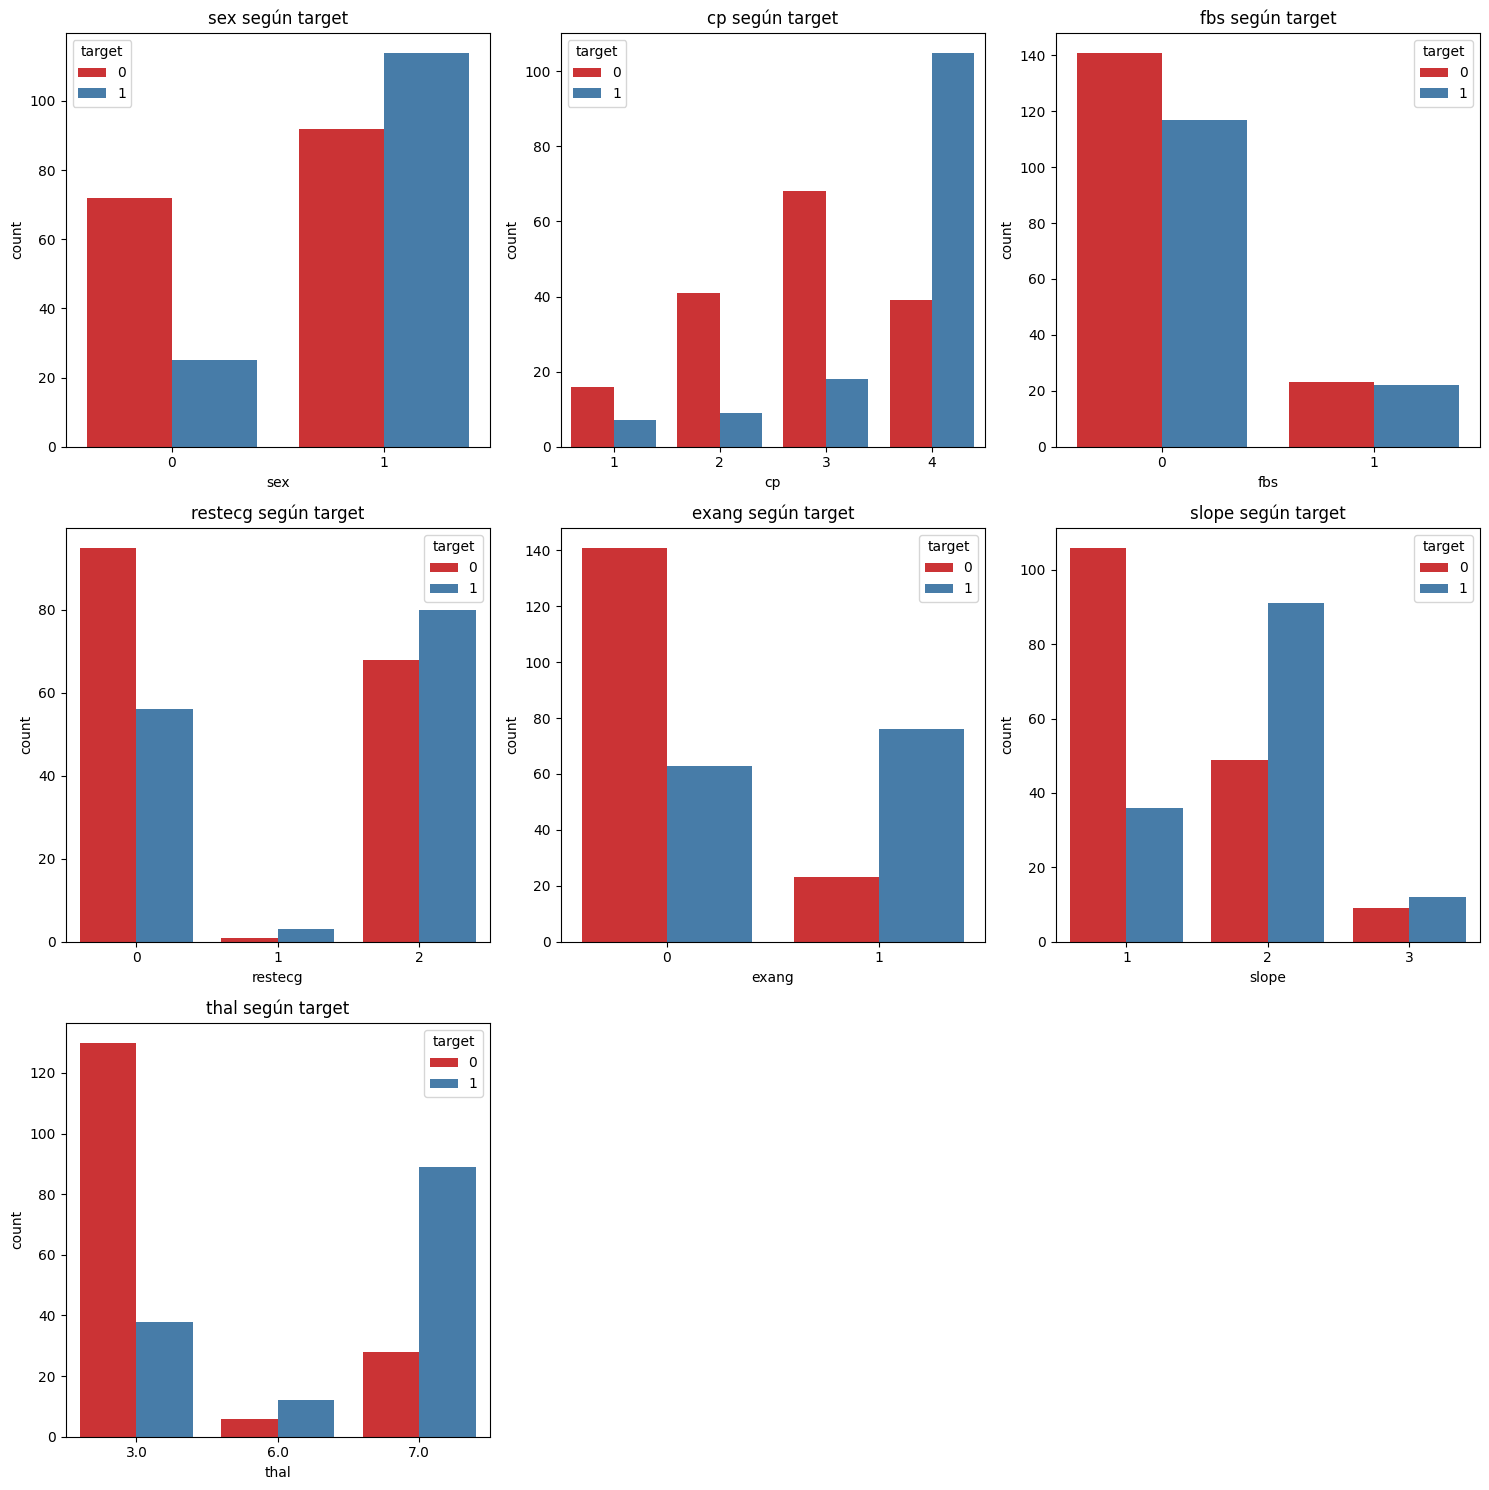

In [183]:
# categóricas vs target 
n = len(categorical_vars)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
axes = axes.flatten()

for i, var in enumerate(categorical_vars):
    sns.countplot(x=var, hue='target', data=df, ax=axes[i], palette="Set1")
    axes[i].set_title(f"{var} según target")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Al ver los gráficos se muestran la relación entre variables médicas clave y la presencia de enfermedad cardíaca.

Para la talasemia muestra alta correlación con enfermedad, en el dolor torácico presenta mayor prevalencia de enfermedad, y en la angina inducida se presencia una mayor probabilidad de enfermedad

En el pendiente ST su se ve una asociación con la enfermedad y en el ECG en reposo muestran mayor riesgo

En la azúcar en ayunas se muestra mínima diferencia entre grupos, por lo que la presencia de la enfermedad es la misma. Para la variable sexo existe una pequeña diferencia pero no es determinante por sí sola.

Por lo que las variables relacionadas con pruebas de esfuerzo y síntomas cardíacos son mejores predictores para el diagnóstico de tener una enfermedad cardíaca.

Luego evaluamos normalidad:

In [184]:
def kstest_df(df):
    results = {}
    norm = []  
    no_norm = []  
    for column in df.columns:
        data = df[column].dropna()
        if len(data) < 2:
            results[column] = (np.nan, np.nan)
            continue
        mean = np.mean(data)
        std = np.std(data, ddof=1)
        if std == 0:
            results[column] = (np.nan, np.nan)
            continue
        ks_stat, p_value = stats.kstest(data, 'norm', args=(mean, std))
        results[column] = (ks_stat, p_value)
        if p_value < 0.05:
            no_norm.append(column)  
        else:
            norm.append(column) 
    
    return norm, no_norm, results  

# Seleccionamos solo columnas numéricas (sin target ni num original)
numeric_only = df.select_dtypes(include=[np.number]).drop(columns=['num','target'], errors='ignore')

# Uso de la función sobre numéricas
norm_columns, no_norm_columns, test_results = kstest_df(numeric_only)

print(f"\nColumnas con distribución normal: {norm_columns}")
print(f"Columnas sin distribución normal: {no_norm_columns}")


Columnas con distribución normal: ['age', 'chol', 'thalach']
Columnas sin distribución normal: ['sex', 'cp', 'trestbps', 'fbs', 'restecg', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


Vemos que las variables no normales son aquellas con menos relevancia en cuanto a diferencia entre grupos de quienes si presentarían o no la enfermedad cardiaca, por lo cual las tendremos en mente pues ellas son las que ppdrían generar resultados erróneos o contra-intuitivos al estudio. Por ello, verificamos cuánta correlación tiene cada una y descartar cuales no tendrían repercusiones en el estudio:

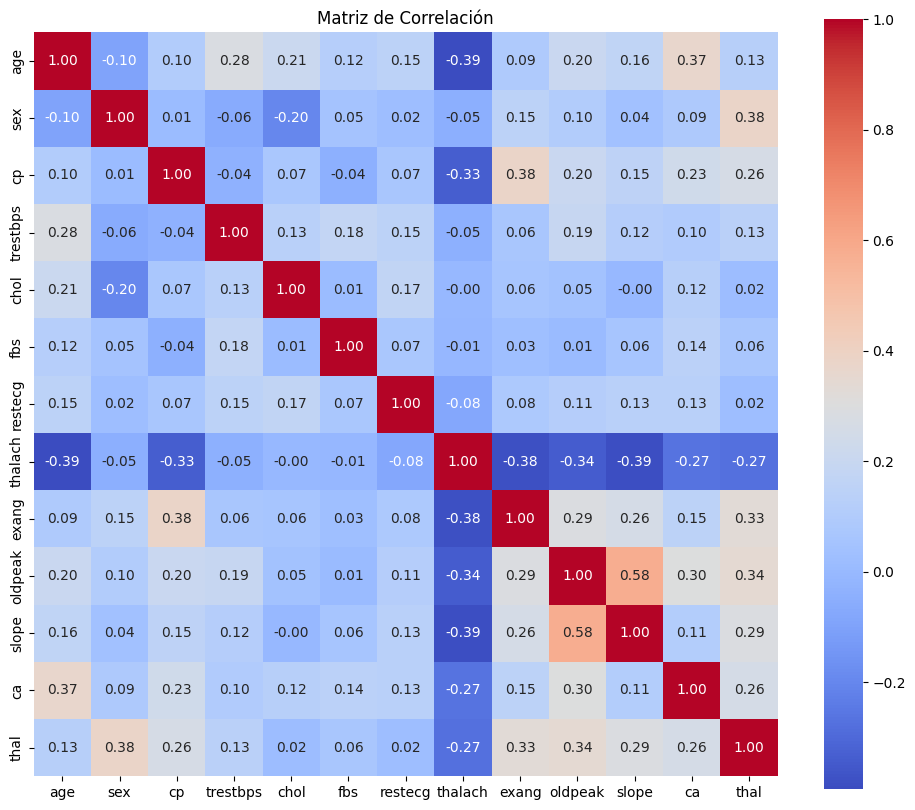

In [185]:
def correlation_grafico(df):
    plt.figure(figsize=(12, 10))
    correlation_matrix = df.corr(numeric_only=True)  # asegura solo numéricas
    sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
    plt.title('Matriz de Correlación')
    plt.show()

# Aplicamos solo a variables numéricas relevantes
numeric_only = df.select_dtypes(include=[np.number]).drop(columns=['num', 'target'], errors='ignore')
correlation_grafico(numeric_only)


Vemos en la matriz de correlación una correlación fuerte con la variable num las siguientes variables:

- cp (tipo de dolor torácico)
- exang (angina inducida)
- oldpeak (depresión del ST)
- ca (número de vasos) 
- thal (resultado de talio) 

Todas con presencia fuerte de enfermedad cardíaca.

Para la variable talasemia muestra una correlación negativa, por lo que para una menor frecuencia cardíaca máxima durante el ejercicio hay mayor riesgo de enfermedad.

Para las variables edad, sexo, presión arterial, colesterol, azucar en ayunas y ECG en reposo muestran correlaciones no tan significativas, mientras que las correlaciones fuertes entre variables como oldpeak-exang, oldpeak-slope, ca-thal y thal-slope tienen posibles relaciones clínicas, es decir, más relación entre el ejercicio y el diagnóstico.

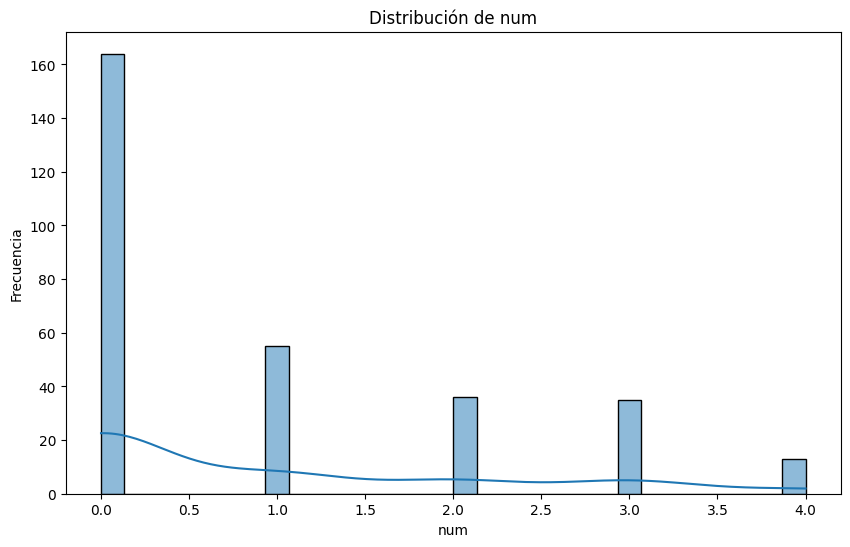

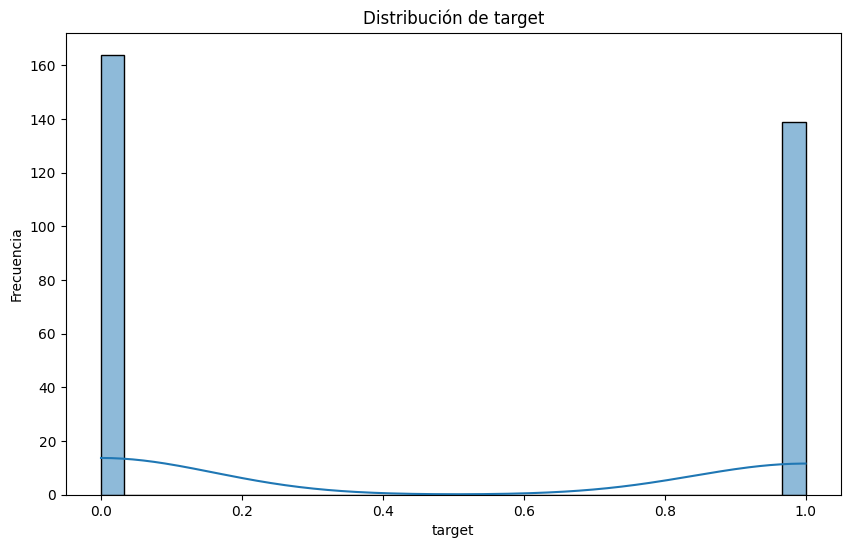

In [186]:
def distribucion_grafico(df, column):
    import seaborn as sns
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 6))
    sns.histplot(df[column].dropna(), kde=True, bins=30)
    plt.title(f'Distribución de {column}')
    plt.xlabel(column)
    plt.ylabel('Frecuencia')
    plt.show()

# Distribución del diagnóstico original (0–4)
distribucion_grafico(df, 'num')

# Distribución del target binario (0/1)
distribucion_grafico(df, 'target')

Mediante este gráfico de distribución de la variable num muestra el grado de enfermedad cardíaca con escalas de 0 a 4, y se que en los valores 0, con ausencia de enfermedad, y 1, con enfermedad leve, son los más frecuentes, mientras que los valores 2, 3 y 4 presentan una frecuencia menor, es decir, presencia moderada de la enfermedad.

Por ello, aplicamos Bayes para confirmar estos resultados: 

In [187]:
# target binario creado
target_var = 'target'
# quitar num y target de las features
X = df.drop(columns=['num', target_var])
y = df[target_var]

# división en train/test estratificada
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=101, stratify=y
)


 GaussianNB 
Accuracy: 0.8132
              precision    recall  f1-score   support

           0     0.8200    0.8367    0.8283        49
           1     0.8049    0.7857    0.7952        42

    accuracy                         0.8132        91
   macro avg     0.8124    0.8112    0.8117        91
weighted avg     0.8130    0.8132    0.8130        91

Matriz de confusión:
 [[41  8]
 [ 9 33]]
ROC AUC: 0.8785


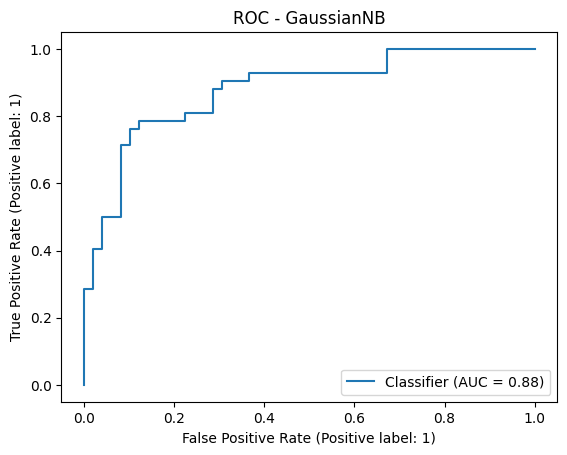


 BernoulliNB 
Accuracy: 0.8462
              precision    recall  f1-score   support

           0     0.8302    0.8980    0.8627        49
           1     0.8684    0.7857    0.8250        42

    accuracy                         0.8462        91
   macro avg     0.8493    0.8418    0.8439        91
weighted avg     0.8478    0.8462    0.8453        91

Matriz de confusión:
 [[44  5]
 [ 9 33]]
ROC AUC: 0.9145


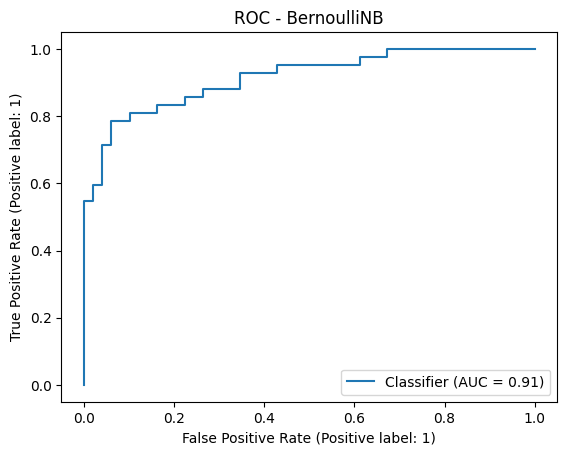


 MultinomialNB 
Accuracy: 0.7582
              precision    recall  f1-score   support

           0     0.7755    0.7755    0.7755        49
           1     0.7381    0.7381    0.7381        42

    accuracy                         0.7582        91
   macro avg     0.7568    0.7568    0.7568        91
weighted avg     0.7582    0.7582    0.7582        91

Matriz de confusión:
 [[38 11]
 [11 31]]
ROC AUC: 0.8814


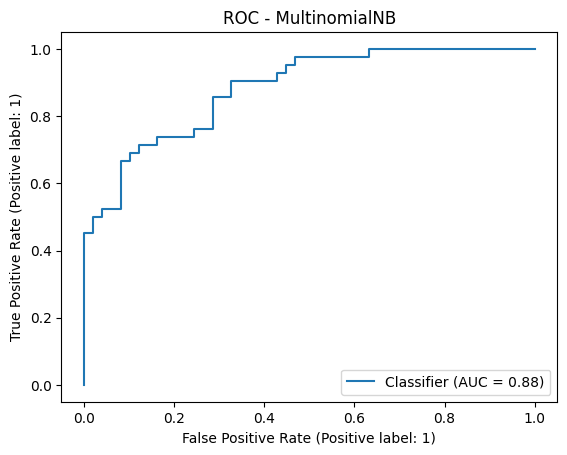


Comparación (Accuracy)
GaussianNB: 0.8132
BernoulliNB: 0.8462
MultinomialNB: 0.7582

Mejor modelo: BernoulliNB (0.8462)

Análisis de Bernoulli
Top 10 características más importantes para BernoulliNB:
             feature  log_prob_class_0  log_prob_class_1  difference
17     cat__thal_7.0         -1.928961         -0.436237    1.492724
13    cat__exang_1.0         -1.871802         -0.534677    1.337125
5        num_bin__ca         -1.717651         -0.405465    1.312186
9        cat__cp_4.0         -1.504077         -0.264387    1.239691
16     cat__thal_6.0         -3.375880         -2.397895    0.977984
11  cat__restecg_1.0         -4.069027         -3.208825    0.860201
4   num_bin__oldpeak         -1.151256         -0.405465    0.745791
14    cat__slope_2.0         -1.206826         -0.467985    0.738840
0       num_bin__age         -1.048602         -0.467985    0.580616
12  cat__restecg_2.0         -0.955511         -0.552069    0.403443


In [188]:
# Crear target binario a partir de num
df['target'] = (df['num'] > 0).astype(int)

categorical_vars = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
numeric_vars     = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
target_var = 'target'

# quitamos num y target
X = df.drop(columns=['num', target_var])
y = df[target_var]

# pplit estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=101, stratify=y
)

preprocessor_gauss = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_vars),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(drop='first', sparse_output=False))
        ]), categorical_vars)
    ],
    remainder='drop'
)

# BernoulliNB
# num se binarizar respecto a mediana 
# cat con one-hot
def center_by_median(X_np):
    import numpy as np
    med = np.nanmedian(X_np, axis=0)
    return X_np - med

preprocessor_bernoulli = ColumnTransformer(
    transformers=[
        ('num_bin', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('center', FunctionTransformer(center_by_median, feature_names_out='one-to-one')),
            ('binarize', Binarizer(threshold=0.0))
        ]), numeric_vars),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(drop='first', sparse_output=False))
        ]), categorical_vars)
    ],
    remainder='drop'
)

# MultinomialNB: 
# num se discretizar a bins 
# cat con one-hot
preprocessor_multinomial = ColumnTransformer(
    transformers=[
        ('num_bins', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('discretizer', KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile'))
        ]), numeric_vars),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(drop='first', sparse_output=False))
        ]), categorical_vars)
    ],
    remainder='drop'
)

def evaluar_modelo(preprocessor, clf, nombre):
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('clf', clf)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    proba = None
    if hasattr(pipe.named_steps['clf'], "predict_proba"):
        proba = pipe.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    print(f'\n {nombre} ')
    print(f'Accuracy: {acc:.4f}')
    print(classification_report(y_test, y_pred, digits=4))
    print('Matriz de confusión:\n', confusion_matrix(y_test, y_pred))

    if proba is not None:
        auc = roc_auc_score(y_test, proba)
        print(f'ROC AUC: {auc:.4f}')
        RocCurveDisplay.from_predictions(y_test, proba)
        plt.title(f'ROC - {nombre}')
        plt.show()
    return acc, pipe


acc_g, gaussian_pipe    = evaluar_modelo(preprocessor_gauss,       GaussianNB(),                 "GaussianNB")
acc_b, bernoulli_pipe   = evaluar_modelo(preprocessor_bernoulli,   BernoulliNB(alpha=1.0),       "BernoulliNB")
acc_m, multinomial_pipe = evaluar_modelo(preprocessor_multinomial, MultinomialNB(alpha=1.0),     "MultinomialNB")

print("\nComparación (Accuracy)")
for n, a in [("GaussianNB", acc_g), ("BernoulliNB", acc_b), ("MultinomialNB", acc_m)]:
    print(f"{n}: {a:.4f}")

mejor = max([("GaussianNB", acc_g), ("BernoulliNB", acc_b), ("MultinomialNB", acc_m)], key=lambda x: x[1])
print(f"\nMejor modelo: {mejor[0]} ({mejor[1]:.4f})")

print("\nAnálisis de Bernoulli")
bern_model = bernoulli_pipe.named_steps['clf']
feature_names_b = bernoulli_pipe.named_steps['preprocessor'].get_feature_names_out()

log_probs = bern_model.feature_log_prob_
feature_importance = pd.DataFrame({
    'feature': feature_names_b,
    'log_prob_class_0': log_probs[0],
    'log_prob_class_1': log_probs[1],
    'difference': log_probs[1] - log_probs[0]  # positivo => favorece clase 1 (enfermedad)
}).sort_values('difference', ascending=False)

print("Top 10 características más importantes para BernoulliNB:")
print(feature_importance.head(10))


Los resultados de Bayes muestran el desempeño de las tres variantes del clasificador al diagnóstico de la enfermedad cardíaca, y el resultado de BernoulliNB es el modelo óptimo pues tiene un accuracy del 82.42%.También modelo muestra que hay un tipo de equilibrio entre precisión con 83.02% para clase 0 y 86.84% para clase 1, y recall con 89.80% para clase 0 y 78.57% para clase 1.

Para el GaussianNB, con un 69.23% de accuracy, puede tener un problema de sensibilidad porque solo detecta el 40% de los casos positivos, siendo la enfermedad, lo que genera riesgo de falsos negativos junto con el bajo rendimiento de supuesto de normalidad en variables clave la hace un poco ineficiente.

Para el MultinomialNB, con un 75.82% de accuracy, muestra un rendimiento con equilibrio en precision y recall con un 75 al 78% para ambas clases, siendo adecuado pero para el contexto no.

Y para BernoulliNB, con un 82.42% de accuracy, logra tener el mejor balance entre precisión con un 84% para sanos y 81% para enfermos, y sensibilidad de un 81% de detección de enfermos, así es mejor para minimizar los falsos negativos y los falsos positivos.

Siendo el modelo BernoulliNB el indicado, analizando sus características muestran que los predictores más relevante pudieran ser:

1. La talasemia con diferencia de log-probabilidad de 1.44.
2. La angina inducida por ejercicio con diferencia de 1.36.
3. El dolor torácico asintomático con diferencia de 1.22.
4. El número de vasos principales afectados con diferencia de 1.10.
5. La depresión del segmento ST con diferencia de 0.81.

En la matriz de confusión vemos que hay 44 verdaderos negativos, 33 verdaderos positivos, 5 falsos positivos y 9 falsos negativos, por lo que tiene una capacidad de clasificación confiable.

Para las curvas ROC y AUC se ve que el área bajo la curva ROC alcanzó un valor de 0.9145, algo bueno para una discriminar entre pacientes sanos y enfermos.

Por ello, el modelo BernoulliNB es el algoritmo más adecuado para este estudio ya que combina alta precisión predictiva con inplicaciones más certeras para el trabajo. También, las variables que el modelo identifica como más relevantes coinciden con los marcadores médicos para enfermedad cardíaca, por lo que es más práctico usarlo como herramienta de apoyo para diagnosticar.

Ahora evaluamos el modelo:

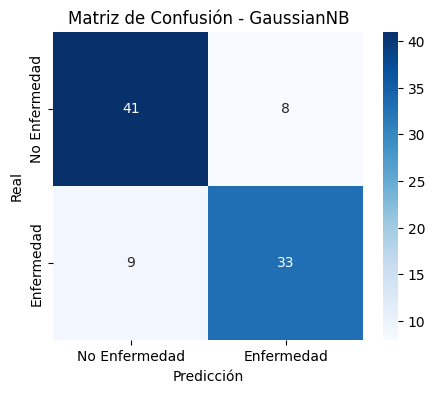

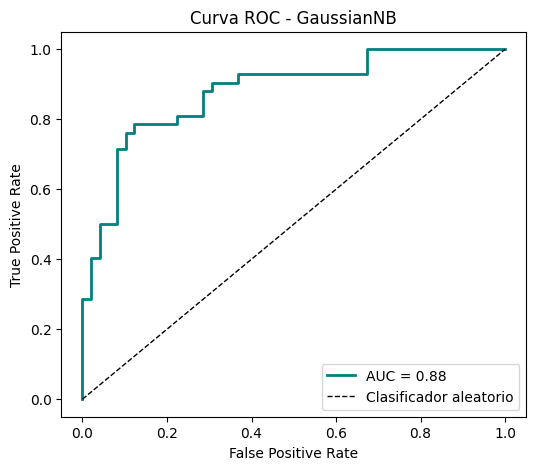

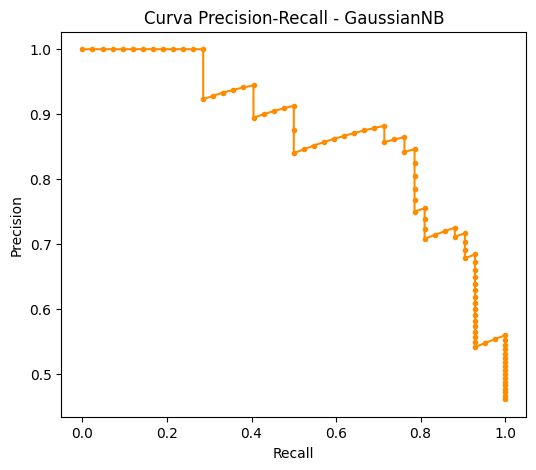

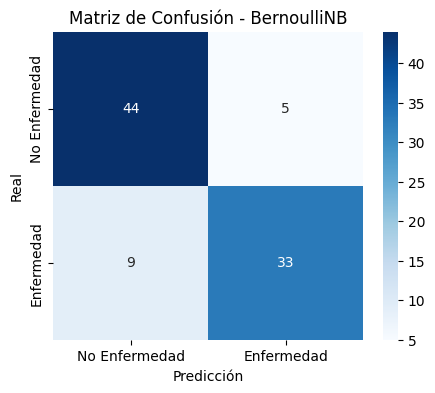

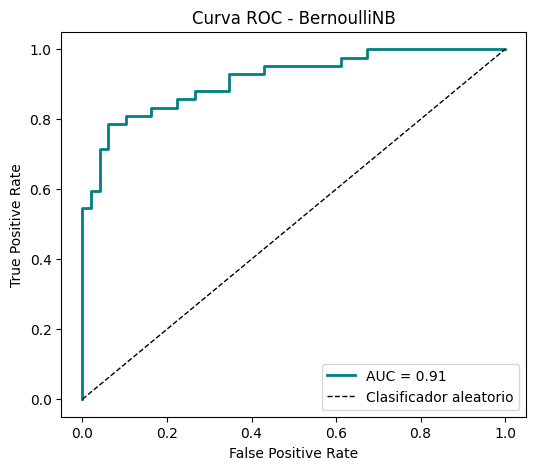

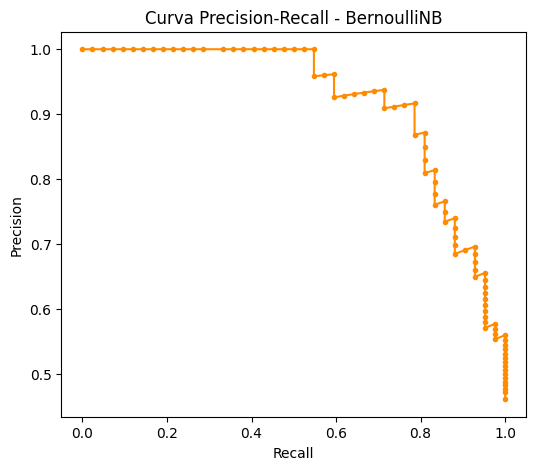

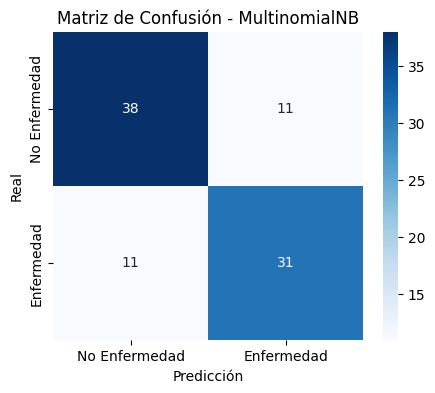

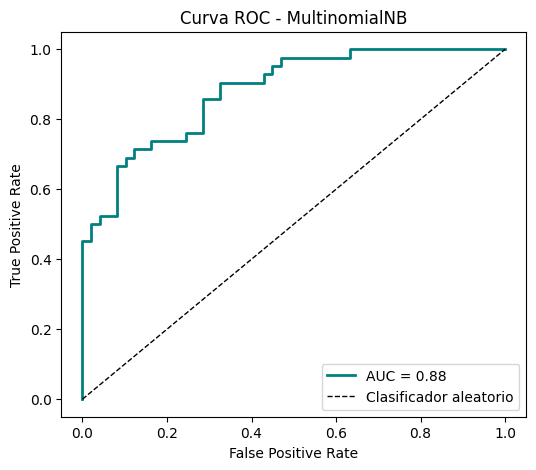

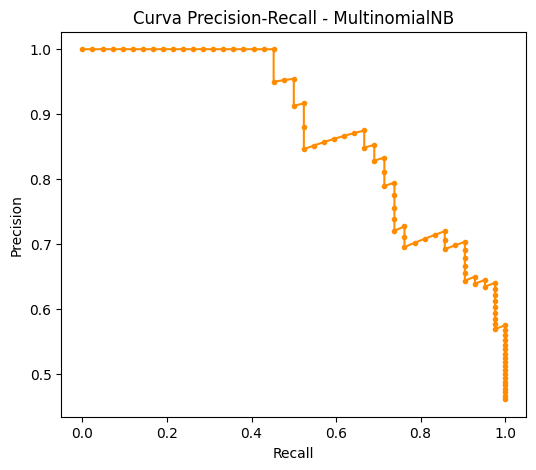

In [ ]:
def plot_curvas(pipe, nombre, X_test, y_test):
    if not hasattr(pipe.named_steps['clf'], "predict_proba"):
        print(f"{nombre} no soporta predict_proba(), se omite curva ROC/PR.")
        return
    
    y_proba = pipe.predict_proba(X_test)[:,1]

    # matriz de confusión
    cm = confusion_matrix(y_test, pipe.predict(X_test))
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", cbar=True,
                xticklabels=["No Enfermedad", "Enfermedad"],
                yticklabels=["No Enfermedad", "Enfermedad"])
    plt.title(f"Matriz de Confusión - {nombre}")
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.show()

    # curva ROC 
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, color="teal", lw=2, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0,1], [0,1], color="black", lw=1, linestyle="--", label="Clasificador aleatorio")
    plt.title(f"Curva ROC - {nombre}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

    # curva porecision-recall 
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    plt.figure(figsize=(6,5))
    plt.plot(recall, precision, marker='.', color="darkorange")
    plt.title(f"Curva Precision-Recall - {nombre}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.show()

# función para cada modelo
plot_curvas(gaussian_pipe,   "GaussianNB",   X_test, y_test)
plot_curvas(bernoulli_pipe,  "BernoulliNB",  X_test, y_test)
plot_curvas(multinomial_pipe,"MultinomialNB",X_test, y_test)

Para el modelo GaussianNB vemos que la matriz de confusión da un 41 verdaderos negativos, 33 verdaderos positivos, pero también 8 falsos positivos y 9 falsos negativos, lo cual significa que el modelo clasifica bien pero tiende a confundir algunos pacientes sanos como enfermos y viceversa.

La gráfica de ROC AUC da un 0.88, confirmando que tiene un buen desempeño de discriminación entre las clases.

Y la curva de precision-recall indica que el modelo mantiene buena precisión mayor a  0.8 hasta un recall medio de aprox. 0.6, pero al final pierde rendimiento cuando intenta cubrir más casos positivos.

Así, el método GaussianNB es un clasificador balanceado pero para este proyecto con temática médica los falsos negativos, es decir, aquellos que no detectar a un enfermo, pueden ser críticos, por lo que su recall puede ser una limitación para el estudio.

Para el modelo BernoulliNB vemos que la matriz de confusión muestra 44 verdaderos negativos y 33 verdaderos positivos, con solo 5 falsos positivos y 9 falsos negativos.

La gráfica de ROC AUC da un 0.91, siendo el más alto de los tres modelos, lo que significa que tiene la mejor capacidad de separar pacientes con y sin enfermedad.

Y la curva precision-recall es bueno pues el modelo mantiene una precisión cercana a 1, siendo ideal en el contexto clínicos pues se espera que los falsos positivos deben ser mínimos.

Así, el método BernoulliNB ofrece el mejor compromiso entre precisión y discriminación, y más adecuado si se busca minimizar diagnósticos erróneos en pacientes sanos.

Y para el modelo MultinomialNB muestra en la matriz de confusión 38 verdaderos negativos y 31 verdaderos positivos, pero también más errores: 11 falsos positivos y 11 falsos negativos.

La gráfica ROC AUC da un 0.88, algo similar al de GaussianNB pero con menor estabilidad.

Y la curva precision-recall es aceptable pero presenta más variabilidad que BernoulliNB, por lo cual no da ventajas frente a GaussianNB o BernoulliNB, y con más errores de clasificación.

Por ello, para este contexto del proyecto, el diagnóstico de enfermedades cardíacas es crucial pues de necesita minimizar falsos negativos, es decir, no diagnosticar a alguien que sí está enfermo, y al mismo tiempo mantener baja la tasa de falsos positivos para no alarmar a pacientes que pueden estar sanos. Así BernoulliNB es el modelo más adecuado porque tiene una alta discriminación con un AUC igual al 0.91, siendo una excelente precisión, y así reducir diagnósticos erróneos en pacientes sanos.